<h2>Muhammad Abdullah
STU-DS-251-930
</h2>

<h1>Iris Dataset Prediction</h1>

<h3>Importing Libraries</h3>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings as wr
wr.filterwarnings('ignore')

<h3>Load Dataset</h3>

In [20]:
dataset= sns.load_dataset("iris")

<h3>To display the first 5 rows of all feature </h3>

In [21]:
print(f"Top 5 rows:\n {dataset.head()}")

Top 5 rows:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


<h3>To display last 7 rows of all features.</h3>

In [22]:
print(f"Last 7 rows:\n {dataset.tail(7)}")

Last 7 rows:
      sepal_length  sepal_width  petal_length  petal_width    species
143           6.8          3.2           5.9          2.3  virginica
144           6.7          3.3           5.7          2.5  virginica
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica


<h3>Check the total number of NULL values contain in specific features.</h3>

In [23]:
dataset.isnull().sum()


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [24]:
# dataset=dataset[["Age","Gender","ParentalEducation","StudyTimeWeekly","Absences","Tutoring","ParentalSupport","GPA","GradeClass"]]


<h3>Check and represent the total information of dataset for preprocessing</h3>

In [25]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<h3>To display the values for each feature like mean, standard daviation, minimum value, maximum value...

In [26]:
dataset.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<h3>Check the correlations of different features for target feature.</h3>

In [27]:
from sklearn.preprocessing import LabelEncoder
LE= LabelEncoder()
dataset.species=LE.fit_transform(dataset.species)
print(dataset.species.unique())

[0 1 2]


In [28]:
print(dataset.corr()["species"].abs().sort_values(ascending=False))

species         1.000000
petal_width     0.956547
petal_length    0.949035
sepal_length    0.782561
sepal_width     0.426658
Name: species, dtype: float64


<h3>To count total number of 0 and 1 values.</h3>

species
0    50
1    50
2    50
Name: count, dtype: int64


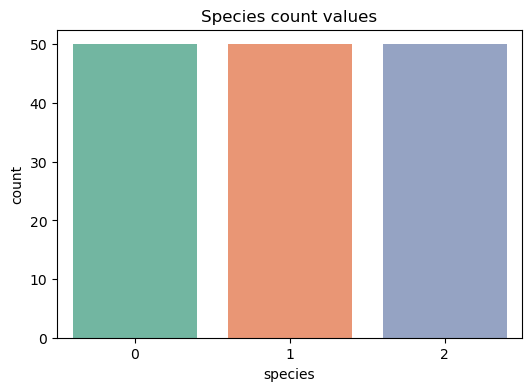

In [29]:
print(dataset['species'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x=dataset.species,palette="Set2")
plt.title("Species count values")
plt.show()

<h3>Seperate the features as for dependent and independent variables.</h3>

In [30]:
x=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

<h3>To do feature scalling for better training model and within range of -1,1 </h3>

In [31]:
# from sklearn.preprocessing import StandardScaler
# SS= StandardScaler()
# x=SS.fit_transform(x)

<h3>Spliting the data for training and testing</h3>

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split( x , y , test_size=0.3, random_state=42, stratify=y)

<h3>Importing and training models.</h3>

In [33]:
from sklearn.linear_model import LogisticRegression
L_model = LogisticRegression(penalty='l2',C=0.1,solver='liblinear',max_iter=200)

L_model.fit(x_train, y_train)

LogisticRegression(C=0.1, max_iter=200, solver='liblinear')

In [49]:
from sklearn.svm import SVC
svm_model = SVC(C=1,kernel='rbf',gamma='scale',probability=True,random_state=42)
svm_model.fit(x_train , y_train)

SVC(C=1, probability=True, random_state=42)

In [35]:
from sklearn.tree import DecisionTreeClassifier
DT_model = DecisionTreeClassifier(max_depth=5,min_samples_split=10,random_state=42)
DT_model.fit(x_train , y_train)


DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [36]:
from sklearn.ensemble import RandomForestClassifier
RF_model = RandomForestClassifier(n_estimators=50,max_depth=5,min_samples_split=10,random_state=42)
RF_model.fit(x_train , y_train)

RandomForestClassifier(max_depth=5, min_samples_split=10, n_estimators=50,
                       random_state=42)

<h3>Predict values by giving x_test.</h3>

In [37]:
# prediction for Logistic Regression
L_pred= L_model.predict(x_test)

# prediction for Support Vector Machine  
svm_pred= svm_model.predict(x_test)

# prediction for Decision Tree
DT_pred= DT_model.predict(x_test)

# prediction for Random Forest
RF_pred= RF_model.predict(x_test)

<h3>Make the model evaluation for Logictic Regresion.</h3>

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print("Accuracy:", accuracy_score(y_test, L_pred))
print("Precision:", precision_score(y_test, L_pred, average='macro'))
print("Recall:", recall_score(y_test, L_pred, average='macro'))
print("F1 Score:", f1_score(y_test, L_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, L_pred))

# precision = precision_score(y_test, y_pred, average='macro')  # or 'weighted'
# recall = recall_score(y_test, y_pred, average='macro')
# f1 = f1_score(y_test, y_pred, average='macro')

Accuracy: 0.8
Precision: 0.875
Recall: 0.7999999999999999
F1 Score: 0.7802197802197802
Confusion Matrix:
 [[15  0  0]
 [ 0  6  9]
 [ 0  0 15]]


<h3>Visualization of Confusion Matrix.</h3>

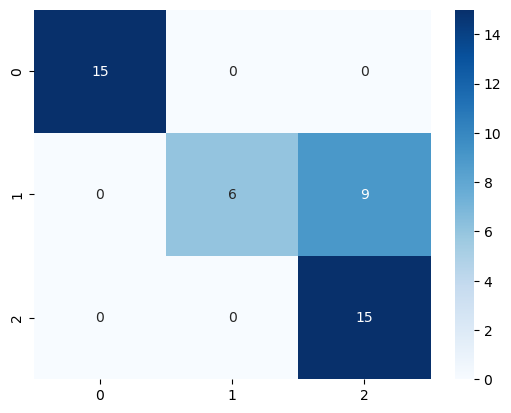

In [39]:
sns.heatmap(confusion_matrix(y_test, L_pred), annot=True, cmap='Blues')
plt.show()

<h3>Make the model evaluation for Support Vector Machine Classifier.</h3>

In [40]:
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred, average='macro'))
print("Recall:", recall_score(y_test, svm_pred, average='macro'))
print("F1 Score:", f1_score(y_test, svm_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))

Accuracy: 0.9555555555555556
Precision: 0.9555555555555556
Recall: 0.9555555555555556
F1 Score: 0.9555555555555556
Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]


<h3>Visualization of Confusion Matrix.</h3>

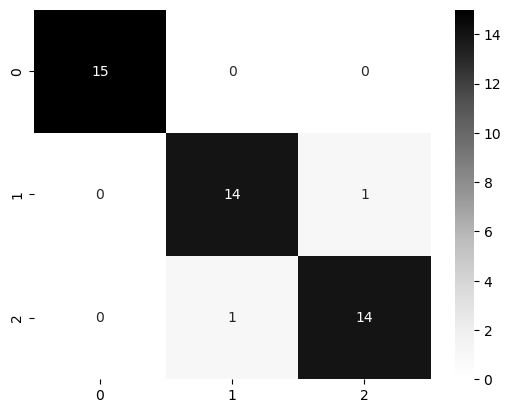

In [41]:
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, cmap='Greys')
plt.show()

<h3>Make the model evaluation for Decision Tree.</h3>

In [42]:
print("Accuracy:", accuracy_score(y_test, DT_pred))
print("Precision:", precision_score(y_test, DT_pred, average='macro'))
print("Recall:", recall_score(y_test, DT_pred, average='macro'))
print("F1 Score:", f1_score(y_test, DT_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, DT_pred))

Accuracy: 0.9333333333333333
Precision: 0.9345238095238096
Recall: 0.9333333333333332
F1 Score: 0.9332591768631814
Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


<h3>Visualization of Confusion Matrix.</h3>

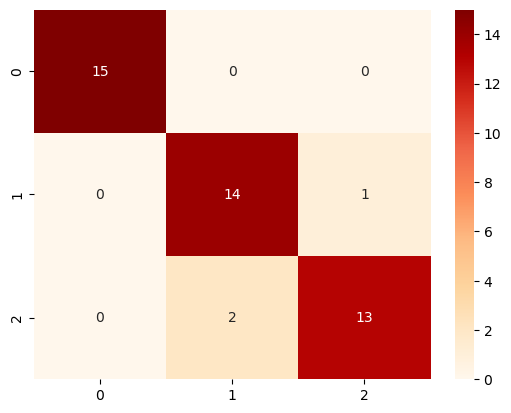

In [43]:
sns.heatmap(confusion_matrix(y_test, DT_pred), annot=True, cmap='OrRd')
plt.show()

<h3>Make the model evaluation for Random Forest.</h3>

In [44]:
print("Accuracy:", accuracy_score(y_test, RF_pred))
print("Precision:", precision_score(y_test, RF_pred, average='macro'))
print("Recall:", recall_score(y_test, RF_pred, average='macro'))
print("F1 Score:", f1_score(y_test, RF_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, RF_pred))

Accuracy: 0.9111111111111111
Precision: 0.9155354449472096
Recall: 0.9111111111111111
F1 Score: 0.9107142857142857
Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


<h3>Visualization of Confusion Matrix.</h3>

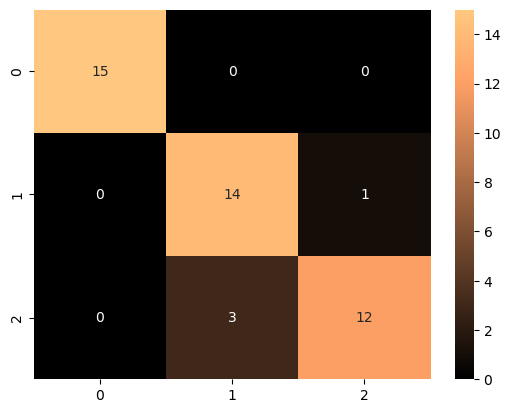

In [45]:
sns.heatmap(confusion_matrix(y_test,RF_pred),annot= True, cmap='copper')
plt.show()

<h2>MODELS PERFORMANCE.</h2>

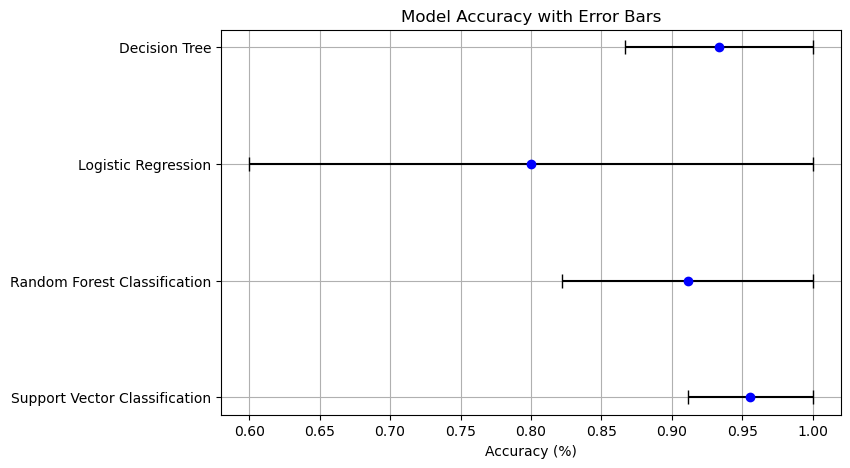

In [46]:
models = ['Support Vector Classification', 'Random Forest Classification',
           'Logistic Regression', 'Decision Tree']

accuracy= [accuracy_score(y_test, svm_pred),accuracy_score(y_test, RF_pred),
          accuracy_score(y_test, L_pred),accuracy_score(y_test, DT_pred)]

errors = [1-accuracy_score(y_test, svm_pred), 1-accuracy_score(y_test, RF_pred),
         1-accuracy_score(y_test, L_pred),1-accuracy_score(y_test, DT_pred)]

# Step 4: Plot
plt.figure(figsize=(8, 5))
plt.errorbar(accuracy, models, xerr=errors, fmt='o', color='blue', ecolor='black', capsize=5)
plt.xlabel('Accuracy (%)')
plt.title('Model Accuracy with Error Bars')
plt.grid(True)
plt.show()

<h2>MODELS PERFORMANCE FOR ACCURACY</h2>

<Axes: title={'center': 'Model Performances'}, xlabel='Algorithms', ylabel='Accuracy score'>

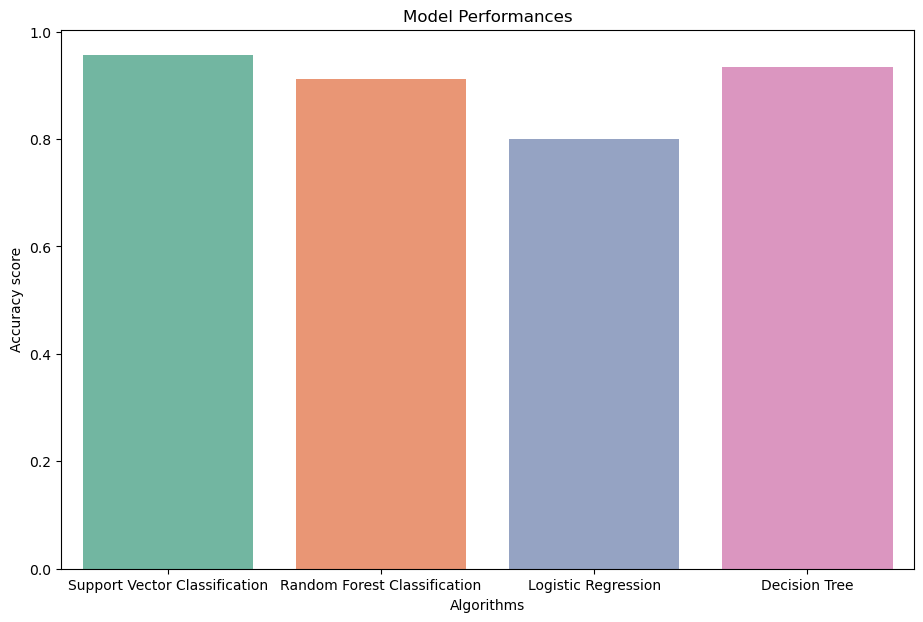

In [47]:
# sns.set(rc={'figure.figsize':(15,8)})
plt.figure(figsize=(11,7))
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")
plt.title("Model Performances")

sns.barplot(x=models, y=accuracy, palette="Set2")

In [48]:
pickle.dump(L_model,open("L_model","wb"))
pickle.dump(svm_model,open("svm_model","wb"))
pickle.dump(DT_model,open("DT_model","wb"))
pickle.dump(RF_model,open("RF_model","wb"))